In [1]:
pip install --upgrade pip && pip install "numpy==1.26.4" "tensorflow>=2.15.0" snntorch h5py scikit-learn matplotlib

  Using cached pip-25.1.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0
    Uninstalling pip-25.0:
      Successfully uninstalled pip-25.0
  Using cached tensorflow-2.19.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached snntorch-0.9.4-py2.py3-none-any.whl.metadata (15 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.10.0-py3-none-any.whl.metadata (6.0 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-manylinux_2_31_x86_64.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.16.0-cp312-cp312-ma

CNN

Scanning jetnet/val: 100%|██████████| 27/27 [00:06<00:00,  4.17it/s]


✅ Saved processed constituent dataset to: cached_data/jet_constituents.npz
Epoch 1/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4924 - loss: 1.2653  

2025-06-30 20:43:42.659328: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_transpose_fusion', 152 bytes spill stores, 120 bytes spill loads



596/596 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4925 - loss: 1.2650 - val_accuracy: 0.6196 - val_loss: 1.0221
Epoch 2/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6230 - loss: 1.0117 - val_accuracy: 0.6281 - val_loss: 0.9917
Epoch 3/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6355 - loss: 0.9819 - val_accuracy: 0.6430 - val_loss: 0.9642
Epoch 4/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6440 - loss: 0.9623 - val_accuracy: 0.6477 - val_loss: 0.9522
Epoch 5/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6490 - loss: 0.9507 - val_accuracy: 0.6495 - val_loss: 0.9480
Epoch 6/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6511 - loss: 0.9466 - val_accuracy: 0.6515 - val_loss: 0.9419
Epoch 7/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6538 - loss: 0.9392 - val_accuracy: 0.6555 - val_loss: 0.9359
Epoch 8/500
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6542 - loss: 0.9367 - val_accuracy: 0.6552

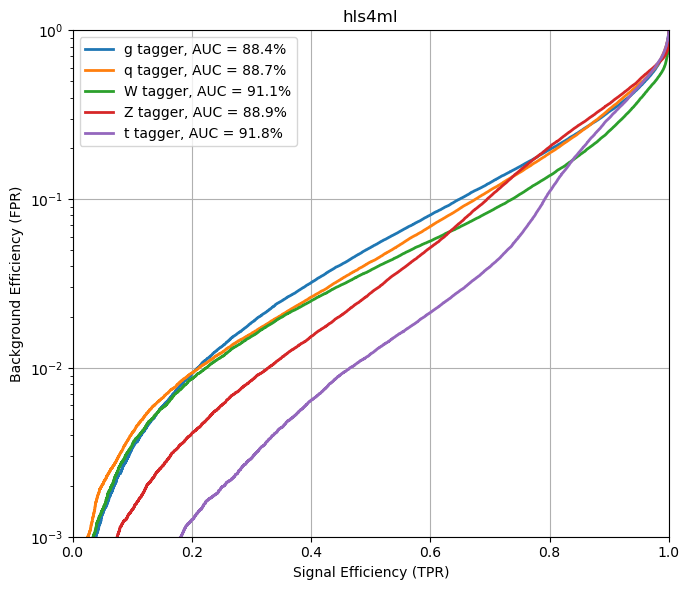

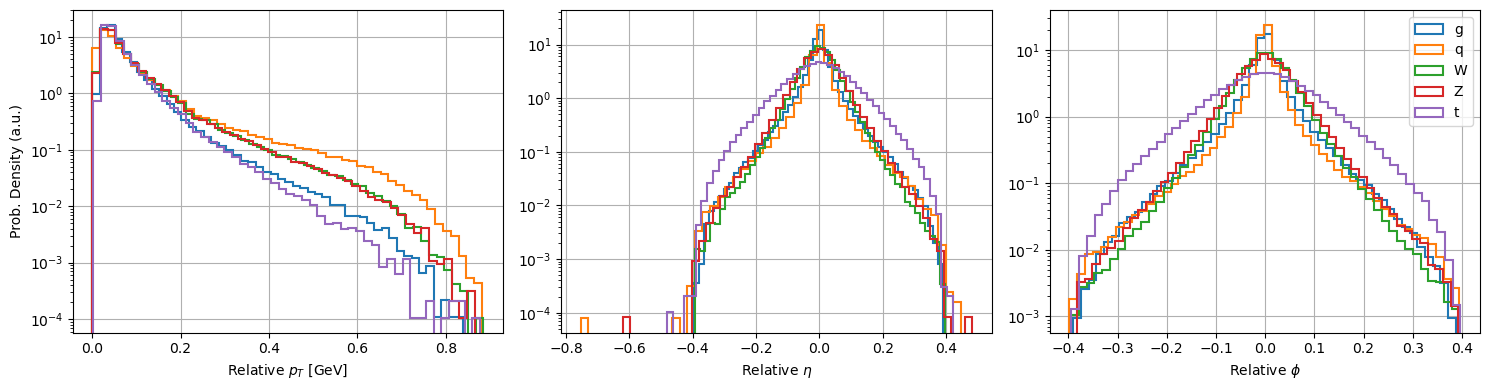

In [8]:
 import os
import numpy as np
import h5py
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
RESULT_PATH = "results/cnn_results_constituents.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
MAX_CONSTITUENTS = 10
FEATURE_IDX = [6, 8, 11]  # Correct: ptrel, etarel, phirel

# === Load and Cache Data ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning " + directory):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"])[:, :, FEATURE_IDX]
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)

                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad_width = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad_width)

                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"✅ Saved processed constituent dataset to: {CACHE_PATH}")

# === Normalize ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

# === Labels One-Hot ===
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# === CNN Model ===
input_layer = Input(shape=(MAX_CONSTITUENTS, 3))
x = Conv1D(64, kernel_size=1, activation='relu')(input_layer)
x = Conv1D(64, kernel_size=1, activation='relu')(x)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
output_layer = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# === Train ===
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=500,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

# === Predict and Save ===
y_pred = model.predict(X_test_scaled, verbose=1)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_test_cat, y_score=y_pred)
print(f"✅ CNN results saved to {RESULT_PATH}")

# === ROC Plot (TPR on x-axis, FPR on y-axis, log scale) ===
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, lw=2, label=f"{name} tagger, AUC = {auc_score*100:.1f}%")

plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("hls4ml")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Feature Distributions (use raw, not scaled) ===
feature_names = [r"Relative $p_T$ [GeV]", r"Relative $\eta$", r"Relative $\phi$"]
bins = 50
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    for j in range(5):
        mask = (y_test == j)
        values = X_test[mask, :, i].flatten()
        values = values[values != 0]  # Remove padding
        plt.hist(
            values, bins=bins, density=True, histtype='step',
            label=CLASS_NAMES[j], color=colors[j], linewidth=1.5
        )
    plt.yscale('log')
    plt.xlabel(feature_names[i])
    if i == 0:
        plt.ylabel("Prob. Density (a.u.)")
    plt.grid(True)

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


ConvSNN

2025-07-02 00:22:00.653864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751415720.678536     134 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751415720.686511     134 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751415720.706348     134 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751415720.706385     134 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751415720.706388     134 computation_placer.cc:177] computation placer alr

✅ Loading cached constituent dataset...

Epoch 1/500


Validating: 100%|██████████| 264/264 [00:09<00:00, 26.68it/s]


Val loss: 1.0842 | Val acc: 0.5769

Epoch 2/500


Validating: 100%|██████████| 264/264 [00:09<00:00, 28.67it/s]


...

Val loss: 0.9623 | Val acc: 0.6525

Epoch 93/500


Validating: 100%|██████████| 264/264 [00:08<00:00, 30.03it/s]


Val loss: 0.9672 | Val acc: 0.6444
Early stopping.


Predicting: 100%|██████████| 264/264 [00:08<00:00, 29.49it/s]


✅ SNN results saved to results/snn_results_constituents.npz


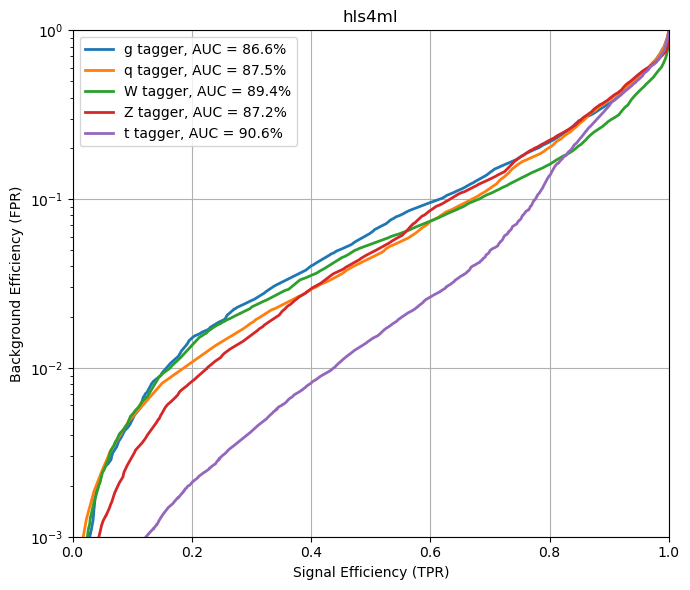

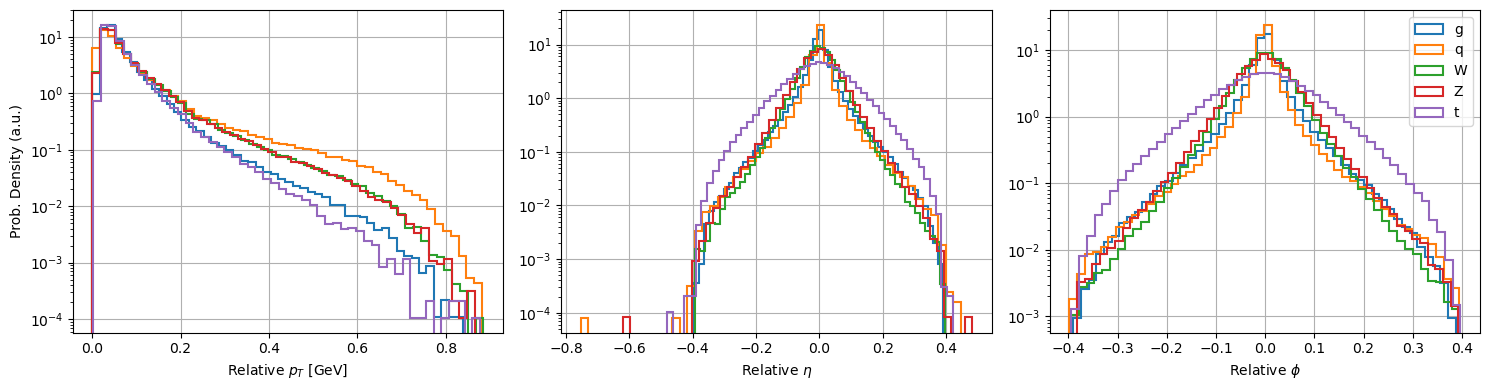

In [4]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
RESULT_PATH = "results/snn_results_constituents.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
MAX_CONSTITUENTS = 10
FEATURE_IDX = [6, 8, 11]  # ptrel, etarel, phirel

# === Load and Cache Data ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"])[:, :, FEATURE_IDX]
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)

                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad_width = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad_width)

                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"✅ Saved processed constituent dataset to: {CACHE_PATH}")

# === Normalize ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

# === Labels One-Hot ===
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# === Prepare Torch Datasets ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1024, shuffle=False)

# === Define Conv-SNN Model with 1 Conv Layer ===
class ConvSNN(nn.Module):
    def __init__(self, input_dim=3, beta=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(32 * MAX_CONSTITUENTS, 64)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(64, 5)
        self.lif3 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spk_out = []
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        x = x.permute(0, 2, 1)

        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            flat = spk1.view(spk1.size(0), -1)
            cur2 = self.fc1(flat)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc2(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            spk_out.append(spk3)

        return torch.stack(spk_out, dim=2)

# === Training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvSNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
best_loss = float('inf')
early_counter = 0
patience = 20

for epoch in range(500):
    print(f"\nEpoch {epoch+1}/500")
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in tqdm(train_loader, desc="Training"):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out.sum(dim=2), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        pred = torch.argmax(out.sum(dim=2), dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    val_loss, val_correct, val_total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Validating"):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.sum(dim=2), yb)
            val_loss += loss.item() * xb.size(0)
            pred = torch.argmax(out.sum(dim=2), dim=1)
            val_correct += (pred == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model.state_dict()
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_model)
model.eval()
y_pred = []
with torch.no_grad():
    for xb in tqdm(test_loader, desc="Predicting"):
        xb = xb[0].to(device)
        out = model(xb)
        probs = out.sum(dim=2).softmax(dim=1).cpu().numpy()
        y_pred.append(probs)

y_pred = np.concatenate(y_pred, axis=0)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_test_cat, y_score=y_pred)
print(f"✅ SNN results saved to {RESULT_PATH}")

# === ROC Plot ===
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, lw=2, label=f"{name} tagger, AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("hls4ml")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Feature Distributions ===
feature_names = [r"Relative $p_T$ [GeV]", r"Relative $\eta$", r"Relative $\phi$"]
bins = 50
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    for j in range(5):
        mask = (y_test == j)
        values = X_test[mask, :, i].flatten()
        values = values[values != 0]
        plt.hist(values, bins=bins, density=True, histtype='step', label=CLASS_NAMES[j], color=colors[j], linewidth=1.5)
    plt.yscale('log')
    plt.xlabel(feature_names[i])
    if i == 0:
        plt.ylabel("Prob. Density (a.u.)")
    plt.grid(True)

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


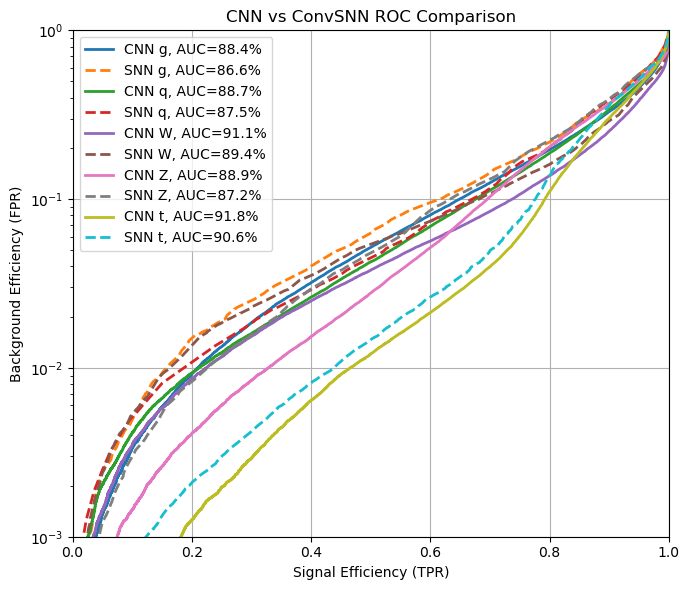

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']

# Load saved results
cnn = np.load("results/cnn_results_constituents.npz")
snn = np.load("results/snn_results_constituents.npz")

plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr_cnn, tpr_cnn, _ = roc_curve(cnn["y_true"][:, i], cnn["y_score"][:, i])
        auc_cnn = auc(fpr_cnn, tpr_cnn)
        plt.plot(tpr_cnn, fpr_cnn, label=f"CNN {name}, AUC={auc_cnn*100:.1f}%", lw=2)

        fpr_snn, tpr_snn, _ = roc_curve(snn["y_true"][:, i], snn["y_score"][:, i])
        auc_snn = auc(fpr_snn, tpr_snn)
        plt.plot(tpr_snn, fpr_snn, "--", label=f"SNN {name}, AUC={auc_snn*100:.1f}%", lw=2)

    except Exception as e:
        print(f"⚠️ Error plotting {name}: {e}")

plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("CNN vs ConvSNN ROC Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


2-conv-layer per particle

✅ Loading cached constituent dataset...

Epoch 1/500


Validating: 100%|██████████| 264/264 [00:10<00:00, 24.74it/s]


Val loss: 1.0872 | Val acc: 0.5850

Epoch 2/500


Validating: 100%|██████████| 264/264 [00:10<00:00, 24.21it/s]


Val loss: 1.0583 | Val acc: 0.6018

Epoch 3/500


...

Val loss: 0.9545 | Val acc: 0.6519

Epoch 89/500


Validating: 100%|██████████| 264/264 [00:10<00:00, 24.87it/s]


Val loss: 0.9437 | Val acc: 0.6531
Early stopping.


Predicting: 100%|██████████| 264/264 [00:10<00:00, 24.16it/s]


✅ SNN results saved to results/snn_results_constituents.npz


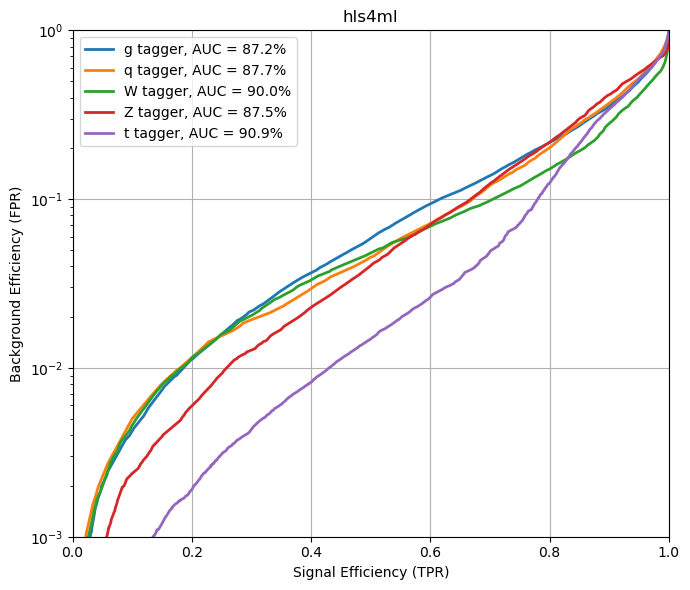

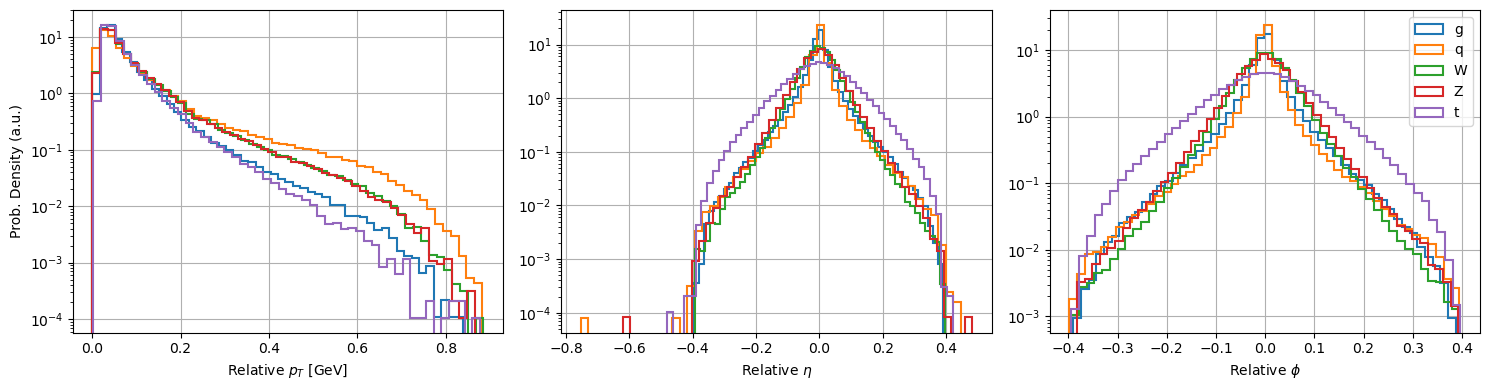

In [5]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
RESULT_PATH = "results/snn_results_constituents.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
MAX_CONSTITUENTS = 10
FEATURE_IDX = [6, 8, 11]  # ptrel, etarel, phirel

# === Load and Cache Data ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"])[:, :, FEATURE_IDX]
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)

                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad_width = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad_width)

                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"✅ Saved processed constituent dataset to: {CACHE_PATH}")

# === Normalize ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

# === Labels One-Hot ===
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# === Prepare Torch Datasets ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1024, shuffle=False)

# === Define Conv-SNN Model with 2 Conv Layers ===
class ConvSNN(nn.Module):
    def __init__(self, input_dim=3, beta=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=1)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(64 * MAX_CONSTITUENTS, 64)
        self.lif3 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(64, 5)
        self.lif4 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spk_out = []
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        x = x.permute(0, 2, 1)

        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            flat = spk2.view(spk2.size(0), -1)
            cur3 = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.fc2(spk3)
            spk4, mem4 = self.lif4(cur4, mem4)
            spk_out.append(spk4)

        return torch.stack(spk_out, dim=2)

# === Training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvSNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
best_loss = float('inf')
early_counter = 0
patience = 20

for epoch in range(500):
    print(f"\nEpoch {epoch+1}/500")
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in tqdm(train_loader, desc="Training"):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out.sum(dim=2), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        pred = torch.argmax(out.sum(dim=2), dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    val_loss, val_correct, val_total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Validating"):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.sum(dim=2), yb)
            val_loss += loss.item() * xb.size(0)
            pred = torch.argmax(out.sum(dim=2), dim=1)
            val_correct += (pred == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model.state_dict()
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_model)
model.eval()
y_pred = []
with torch.no_grad():
    for xb in tqdm(test_loader, desc="Predicting"):
        xb = xb[0].to(device)
        out = model(xb)
        probs = out.sum(dim=2).softmax(dim=1).cpu().numpy()
        y_pred.append(probs)

y_pred = np.concatenate(y_pred, axis=0)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_test_cat, y_score=y_pred)
print(f"✅ SNN results saved to {RESULT_PATH}")

# === ROC Plot ===
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, lw=2, label=f"{name} tagger, AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("hls4ml")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Feature Distributions ===
feature_names = [r"Relative $p_T$ [GeV]", r"Relative $\eta$", r"Relative $\phi$"]
bins = 50
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    for j in range(5):
        mask = (y_test == j)
        values = X_test[mask, :, i].flatten()
        values = values[values != 0]
        plt.hist(values, bins=bins, density=True, histtype='step', label=CLASS_NAMES[j], color=colors[j], linewidth=1.5)
    plt.yscale('log')
    plt.xlabel(feature_names[i])
    if i == 0:
        plt.ylabel("Prob. Density (a.u.)")
    plt.grid(True)

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


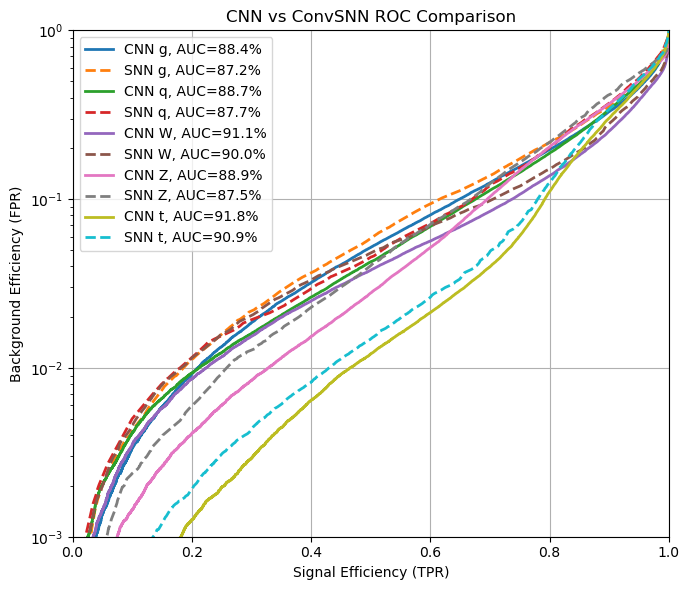

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']

# Load saved results
cnn = np.load("results/cnn_results_constituents.npz")
snn = np.load("results/snn_results_constituents.npz")

plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr_cnn, tpr_cnn, _ = roc_curve(cnn["y_true"][:, i], cnn["y_score"][:, i])
        auc_cnn = auc(fpr_cnn, tpr_cnn)
        plt.plot(tpr_cnn, fpr_cnn, label=f"CNN {name}, AUC={auc_cnn*100:.1f}%", lw=2)

        fpr_snn, tpr_snn, _ = roc_curve(snn["y_true"][:, i], snn["y_score"][:, i])
        auc_snn = auc(fpr_snn, tpr_snn)
        plt.plot(tpr_snn, fpr_snn, "--", label=f"SNN {name}, AUC={auc_snn*100:.1f}%", lw=2)

    except Exception as e:
        print(f"⚠️ Error plotting {name}: {e}")

plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("CNN vs ConvSNN ROC Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


2-conv-layer per feature

✅ Loading cached constituent dataset...


/tmp/ipykernel_138/1634012949.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_checkpoint)


🔁 Resuming from checkpoint: checkpoints/epoch_123.pt

Epoch 124/500


Validating: 100%|██████████| 264/264 [00:12<00:00, 21.09it/s]


Val loss: 0.9419 | Val acc: 0.6517
Early stopping.


Predicting: 100%|██████████| 264/264 [00:11<00:00, 22.56it/s]


✅ SNN results saved to results/snn_results_constituents_feature_integration.npz


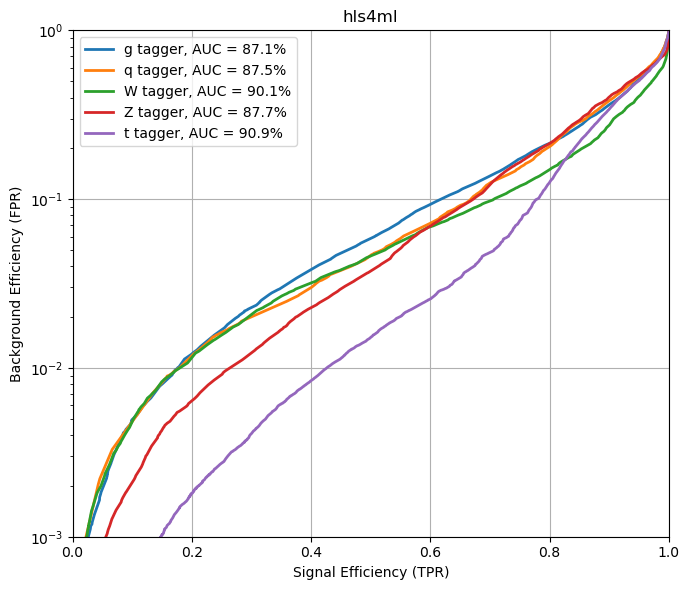

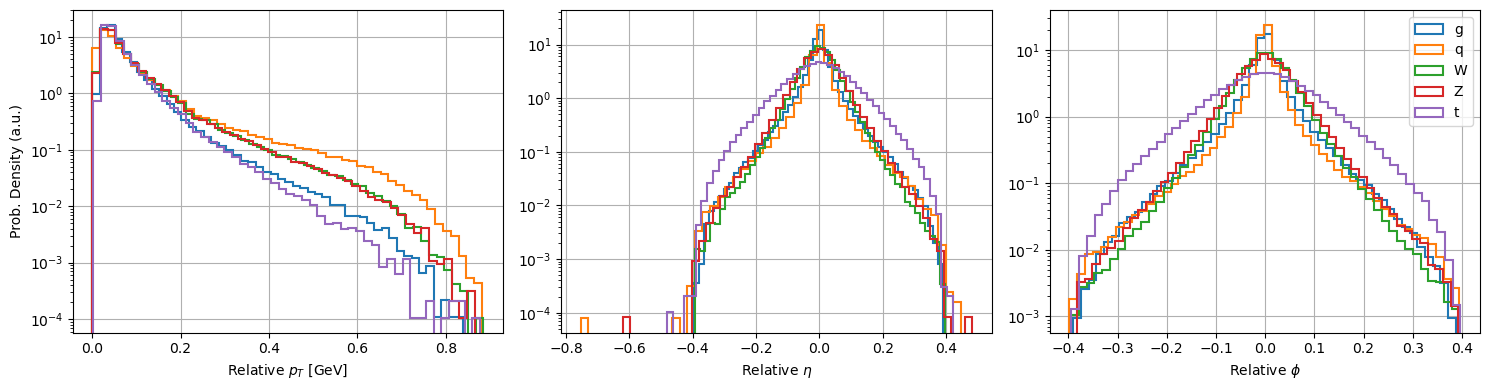

In [5]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
RESULT_PATH = "results/snn_results_constituents_feature_integration.npz"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
MAX_CONSTITUENTS = 10
FEATURE_IDX = [6, 8, 11]  # ptrel, etarel, phirel

# === Load and Cache Data ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"])[:, :, FEATURE_IDX]
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)

                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad_width = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad_width)

                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"✅ Saved processed constituent dataset to: {CACHE_PATH}")

# === Normalize ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

# === Labels One-Hot ===
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# === Prepare Torch Datasets ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1024, shuffle=False)

# === Define Conv-SNN Model with 2 Conv Layers ===
class ConvSNN(nn.Module):
    def __init__(self, input_dim=3, beta=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=1)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(64 * MAX_CONSTITUENTS, 64)
        self.lif3 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(64, 5)
        self.lif4 = snn.Leaky(beta=beta)

    def forward(self, x, num_steps=20):
        spk_out = []
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        x = x.permute(0, 2, 1)

        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            flat = spk2.view(spk2.size(0), -1)
            cur3 = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.fc2(spk3)
            spk4, mem4 = self.lif4(cur4, mem4)
            spk_out.append(spk4)

        return torch.stack(spk_out, dim=2)

# === Training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvSNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
best_loss = float('inf')
best_model = None

start_epoch = 0
checkpoint_files = sorted(glob("checkpoints/epoch_*.pt"))
os.makedirs("checkpoints", exist_ok=True)
if checkpoint_files:
    latest_checkpoint = checkpoint_files[-1]
    print(f"🔁 Resuming from checkpoint: {latest_checkpoint}")
    checkpoint = torch.load(latest_checkpoint)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    best_loss = checkpoint['best_loss']
    early_counter = checkpoint['early_counter']
else:
    early_counter = 0

for epoch in range(start_epoch, 500):
    print(f"\nEpoch {epoch+1}/500")
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in tqdm(train_loader, desc="Training"):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out.sum(dim=2), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        pred = torch.argmax(out.sum(dim=2), dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    val_loss, val_correct, val_total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Validating"):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.sum(dim=2), yb)
            val_loss += loss.item() * xb.size(0)
            pred = torch.argmax(out.sum(dim=2), dim=1)
            val_correct += (pred == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'early_counter': early_counter,
        'best_loss': best_loss,
    }, f"checkpoints/epoch_{epoch+1:03d}.pt")

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model.state_dict()
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= patience:
            print("Early stopping.")
            break

if best_model is not None:
    model.load_state_dict(best_model)
model.eval()
y_pred = []
with torch.no_grad():
    for xb in tqdm(test_loader, desc="Predicting"):
        xb = xb[0].to(device)
        out = model(xb)
        probs = out.sum(dim=2).softmax(dim=1).cpu().numpy()
        y_pred.append(probs)

y_pred = np.concatenate(y_pred, axis=0)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_test_cat, y_score=y_pred)
print(f"✅ SNN results saved to {RESULT_PATH}")

# === ROC Plot ===
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, lw=2, label=f"{name} tagger, AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("hls4ml")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Feature Distributions ===
feature_names = [r"Relative $p_T$ [GeV]", r"Relative $\eta$", r"Relative $\phi$"]
bins = 50
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    for j in range(5):
        mask = (y_test == j)
        values = X_test[mask, :, i].flatten()
        values = values[values != 0]
        plt.hist(values, bins=bins, density=True, histtype='step', label=CLASS_NAMES[j], color=colors[j], linewidth=1.5)
    plt.yscale('log')
    plt.xlabel(feature_names[i])
    if i == 0:
        plt.ylabel("Prob. Density (a.u.)")
    plt.grid(True)

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


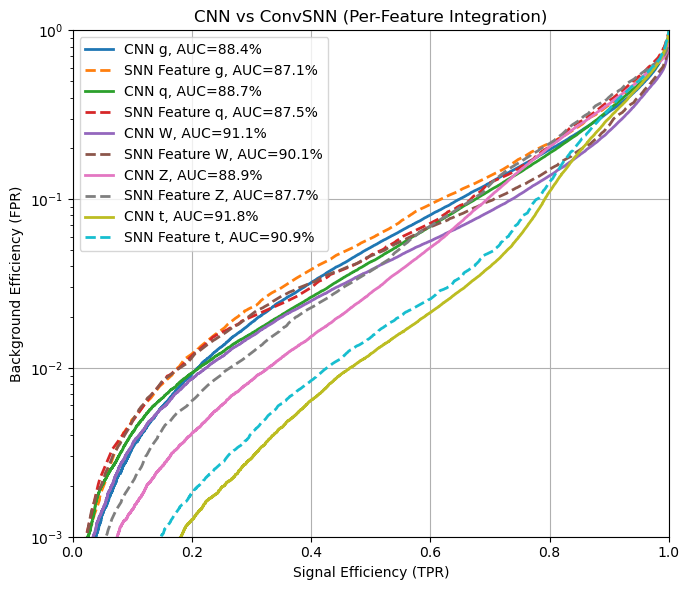

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']

# Load saved results
cnn = np.load("results/cnn_results_constituents.npz")
snn = np.load("results/snn_results_constituents_feature_integration.npz")  # per-feature integration

plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr_cnn, tpr_cnn, _ = roc_curve(cnn["y_true"][:, i], cnn["y_score"][:, i])
        auc_cnn = auc(fpr_cnn, tpr_cnn)
        plt.plot(tpr_cnn, fpr_cnn, label=f"CNN {name}, AUC={auc_cnn*100:.1f}%", lw=2)

        fpr_snn, tpr_snn, _ = roc_curve(snn["y_true"][:, i], snn["y_score"][:, i])
        auc_snn = auc(fpr_snn, tpr_snn)
        plt.plot(tpr_snn, fpr_snn, "--", label=f"SNN Feature {name}, AUC={auc_snn*100:.1f}%", lw=2)

    except Exception as e:
        print(f"⚠️ Error plotting {name}: {e}")

plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("CNN vs ConvSNN (Per-Feature Integration)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


MLP-Mixer

✅ Loading cached constituent dataset...

Epoch 1/500


Validating: 100%|██████████| 264/264 [00:02<00:00, 116.72it/s]


Val loss: 1.0260 | Val acc: 0.6122

Epoch 2/500


Validating: 100%|██████████| 264/264 [00:01<00:00, 139.27it/s]


Val loss: 0.9914 | Val acc: 0.6315

Epoch 3/500


...

Val loss: 0.8886 | Val acc: 0.6766

Epoch 185/500


Validating: 100%|██████████| 264/264 [00:02<00:00, 106.14it/s]


Val loss: 0.8878 | Val acc: 0.6754
Early stopping.


Predicting: 100%|██████████| 264/264 [00:01<00:00, 140.72it/s]


✅ MLP results saved to results/mlp_mixer_results_constituents.npz


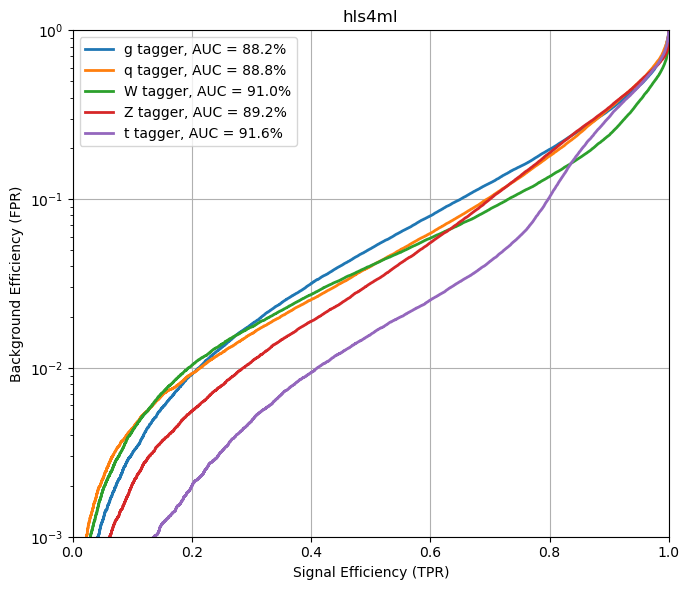

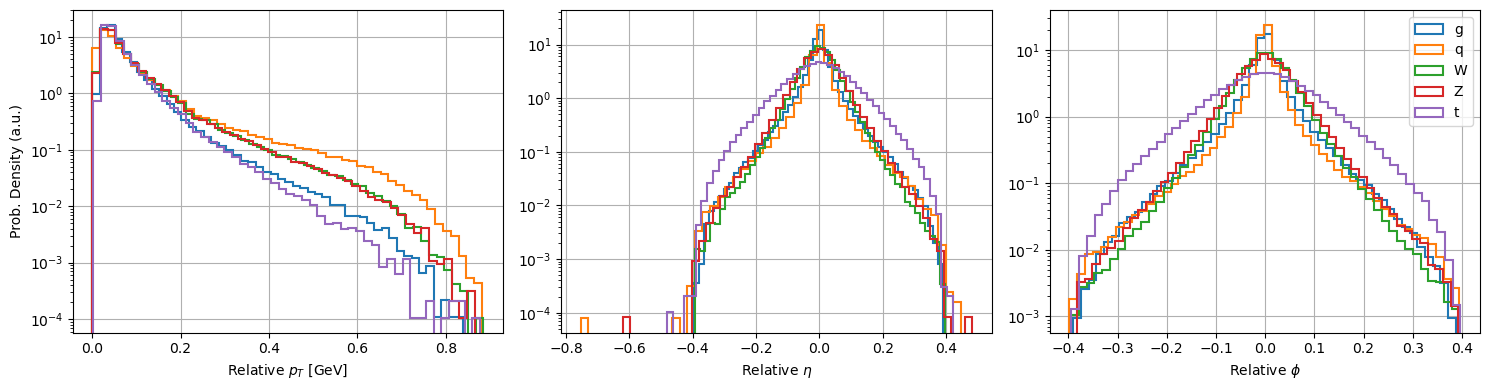

In [10]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# === CONFIG ===
TRAIN_DIR = "jetnet/train"
VAL_DIR = "jetnet/val"
CACHE_PATH = "cached_data/jet_constituents.npz"
RESULT_PATH = "results/mlp_mixer_results_constituents.npz"
CHECKPOINT_DIR = "checkpoints_mlp"
CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']
MAX_CONSTITUENTS = 10
FEATURE_IDX = [6, 8, 11]  # ptrel, etarel, phirel
INPUT_DIM = MAX_CONSTITUENTS * len(FEATURE_IDX)

# === Load and Cache Data ===
if os.path.exists(CACHE_PATH):
    print("✅ Loading cached constituent dataset...")
    data = np.load(CACHE_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
else:
    def load_constituents(directory):
        X_list, y_list = [], []
        h5_files = sorted(glob(os.path.join(directory, "*.h5")))
        for fpath in tqdm(h5_files, desc=f"Scanning {directory}"):
            try:
                with h5py.File(fpath, "r") as f:
                    jets = np.array(f["jets"])
                    constituents = np.array(f["jetConstituentList"][:, :, FEATURE_IDX])
                    labels = jets[:, -6:-1]
                    y = np.argmax(labels, axis=1)

                    cons = constituents[:, :MAX_CONSTITUENTS, :]
                    if cons.shape[1] < MAX_CONSTITUENTS:
                        pad_width = ((0, 0), (0, MAX_CONSTITUENTS - cons.shape[1]), (0, 0))
                        cons = np.pad(cons, pad_width)

                    X_list.append(cons)
                    y_list.append(y)
            except Exception as e:
                print(f"⚠️ Skipped {fpath}: {e}")
        return np.concatenate(X_list), np.concatenate(y_list)

    X_train, y_train = load_constituents(TRAIN_DIR)
    X_test, y_test = load_constituents(VAL_DIR)

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez_compressed(CACHE_PATH, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"✅ Saved processed constituent dataset to: {CACHE_PATH}")

# === Normalize ===
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

# === Labels One-Hot ===
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# === Prepare Torch Datasets ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1024, shuffle=False)

# === Define MLP-Mixer Model ===
class MLPMixer(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp_particle = nn.Sequential(
            nn.Linear(MAX_CONSTITUENTS, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        self.mlp_feature = nn.Sequential(
            nn.Linear(INPUT_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.classifier = nn.Sequential(
            nn.Linear(35, 32),
            nn.ReLU(),
            nn.Linear(32, 5)
        )

    def forward(self, x):
        x_perm = x.permute(0, 2, 1)  # [B, 3, 10]
        x_particle = self.mlp_particle(x_perm).squeeze(-1)  # [B, 3]
        x_feature = self.mlp_feature(x.view(x.size(0), -1))  # [B, 32]
        x_cat = torch.cat([x_particle, x_feature], dim=1)  # [B, 3+32]
        return self.classifier(x_cat)

# === Training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPMixer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
best_loss = float('inf')
best_model = None
start_epoch = 0

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_files = sorted(glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pt")))
if checkpoint_files:
    latest_checkpoint = checkpoint_files[-1]
    print(f"🔁 Resuming from checkpoint: {latest_checkpoint}")
    checkpoint = torch.load(latest_checkpoint)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    best_loss = checkpoint['best_loss']
    early_counter = checkpoint['early_counter']
else:
    early_counter = 0

patience = 20
for epoch in range(start_epoch, 500):
    print(f"\nEpoch {epoch+1}/500")
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in tqdm(train_loader, desc="Training"):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        pred = torch.argmax(out, dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    val_loss, val_correct, val_total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Validating"):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            pred = torch.argmax(out, dim=1)
            val_correct += (pred == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'early_counter': early_counter,
        'best_loss': best_loss,
    }, os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt"))

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model.state_dict()
        early_counter = 0
    else:
        early_counter += 1
        if early_counter >= patience:
            print("Early stopping.")
            break

if best_model is not None:
    model.load_state_dict(best_model)
model.eval()
y_pred = []
with torch.no_grad():
    for xb in tqdm(test_loader, desc="Predicting"):
        xb = xb[0].to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        y_pred.append(probs)

y_pred = np.concatenate(y_pred, axis=0)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)
np.savez_compressed(RESULT_PATH, y_true=y_test_cat, y_score=y_pred)
print(f"✅ MLP results saved to {RESULT_PATH}")

# === ROC Plot ===
plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(tpr, fpr, lw=2, label=f"{name} tagger, AUC = {auc_score*100:.1f}%")
plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("hls4ml")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Feature Distributions ===
feature_names = [r"Relative $p_T$ [GeV]", r"Relative $\eta$", r"Relative $\phi$"]
bins = 50
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    for j in range(5):
        mask = (y_test == j)
        values = X_test[mask, :, i].flatten()
        values = values[values != 0]
        plt.hist(values, bins=bins, density=True, histtype='step', label=CLASS_NAMES[j], color=colors[j], linewidth=1.5)
    plt.yscale('log')
    plt.xlabel(feature_names[i])
    if i == 0:
        plt.ylabel("Prob. Density (a.u.)")
    plt.grid(True)

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


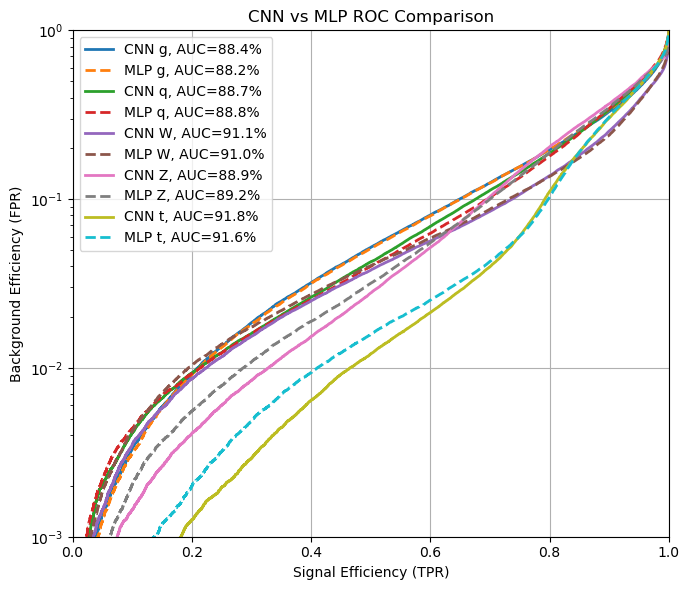

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

CLASS_NAMES = ['g', 'q', 'W', 'Z', 't']

# Load saved results
cnn = np.load("results/cnn_results_constituents.npz")
mlp = np.load("results/mlp_mixer_results_constituents.npz")

plt.figure(figsize=(7, 6))
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr_cnn, tpr_cnn, _ = roc_curve(cnn["y_true"][:, i], cnn["y_score"][:, i])
        auc_cnn = auc(fpr_cnn, tpr_cnn)
        plt.plot(tpr_cnn, fpr_cnn, label=f"CNN {name}, AUC={auc_cnn*100:.1f}%", lw=2)

        fpr_mlp, tpr_mlp, _ = roc_curve(mlp["y_true"][:, i], mlp["y_score"][:, i])
        auc_mlp = auc(fpr_mlp, tpr_mlp)
        plt.plot(tpr_mlp, fpr_mlp, '--', label=f"MLP {name}, AUC={auc_mlp*100:.1f}%", lw=2)

    except Exception as e:
        print(f"⚠️ Error plotting {name}: {e}")

plt.yscale('log')
plt.xlim([0.0, 1.0])
plt.ylim([1e-3, 1.0])
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Background Efficiency (FPR)")
plt.title("CNN vs MLP ROC Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
